In [1]:
import os
import numpy as np
import scipy.io as sio
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
import sys
sys.path.append("..") 
from processing import  load_UCI_dataset, train_resnet1d, plot_loss_vs_epoch, evaluate_resnet_vitaldb, train_resnet1d_se, train_resnet1d_cbam, train_resnet1d_dilated

In [3]:
WINDOW_SIZE = 625
STEP_SIZE = 312

BASE_DIR = "/data1/yashvi_bhuva/BP_estimation_using_PPG/VitalDB/ML/non_fiducial_features/5sec_50%overlap/vitaldb_checkpoints"

X_train, y_train, X_val, y_val, X_test, y_test = load_UCI_dataset(
    WINDOW_SIZE=WINDOW_SIZE,
    STEP_SIZE=STEP_SIZE
)

Total recordings: 12000
Train recordings: 9600
Validation recordings: 1200
Test recordings: 1200


100%|██████████| 9600/9600 [02:33<00:00, 62.70it/s]


Skipped recordings: 81


100%|██████████| 1200/1200 [00:20<00:00, 57.63it/s]


Skipped recordings: 7


100%|██████████| 1200/1200 [00:20<00:00, 57.22it/s]

Skipped recordings: 9


Device: cuda
X_train: torch.Size([829483, 1, 625])
y_train: torch.Size([829483, 2])
X_val: torch.Size([104736, 1, 625])
y_val: torch.Size([104736, 2])
X_test: torch.Size([105176, 1, 625])
y_test: torch.Size([105176, 2])
Epoch 01/100 | Train Loss: 3495.9090 | Val Loss: 198.5306 | Train SBP RMSE: 77.016 | Train DBP RMSE: 32.563 | Val SBP RMSE: 17.500 | Val DBP RMSE: 9.529 | LR: 1.00e-04
Epoch 02/100 | Train Loss: 195.7015 | Val Loss: 179.0056 | Train SBP RMSE: 17.296 | Train DBP RMSE: 9.604 | Val SBP RMSE: 16.668 | Val DBP RMSE: 8.956 | LR: 1.00e-04
Epoch 03/100 | Train Loss: 162.8209 | Val Loss: 181.8883 | Train SBP RMSE: 15.729 | Train DBP RMSE: 8.845 | Val SBP RMSE: 16.748 | Val DBP RMSE: 9.127 | LR: 1.00e-04
Epoch 04/100 | Train Loss: 143.4229 | Val Loss: 161.6497 | Train SBP RMSE: 14.717 | Train DBP RMSE: 8.382 | Val SBP RMSE: 15.787 | Val DBP RMSE: 8.607 | LR: 1.00e-04
Epoch 05/100 | Train Loss: 130.0971 | Val Loss: 163.2235 | Train SBP RMSE: 13.975 | Train DBP RMSE: 8.055 | Val SB

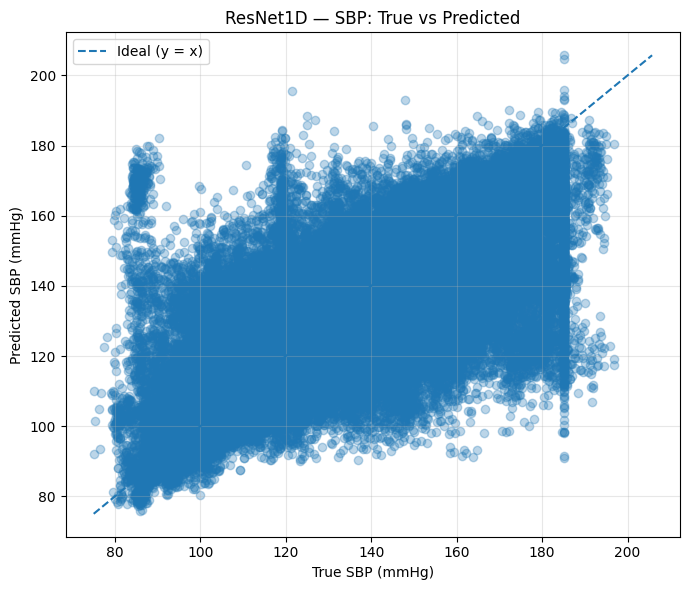

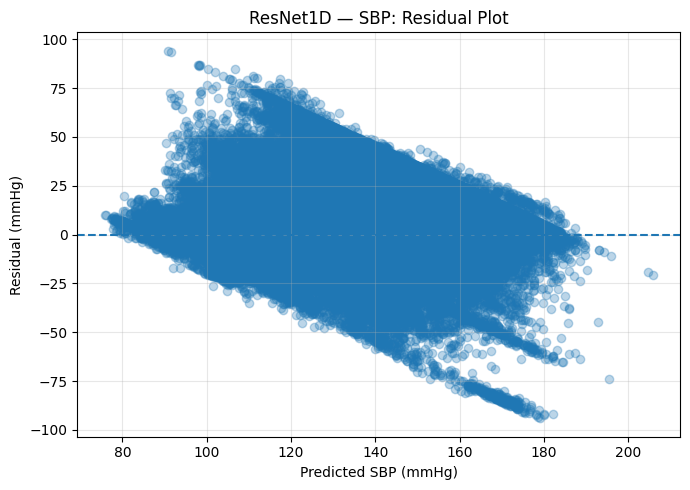

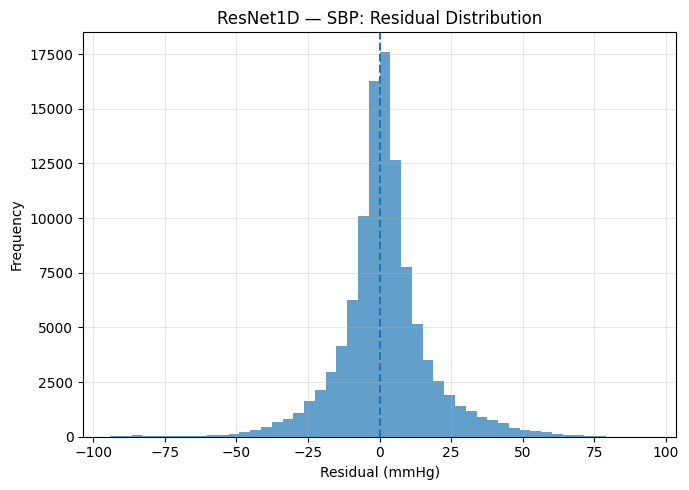

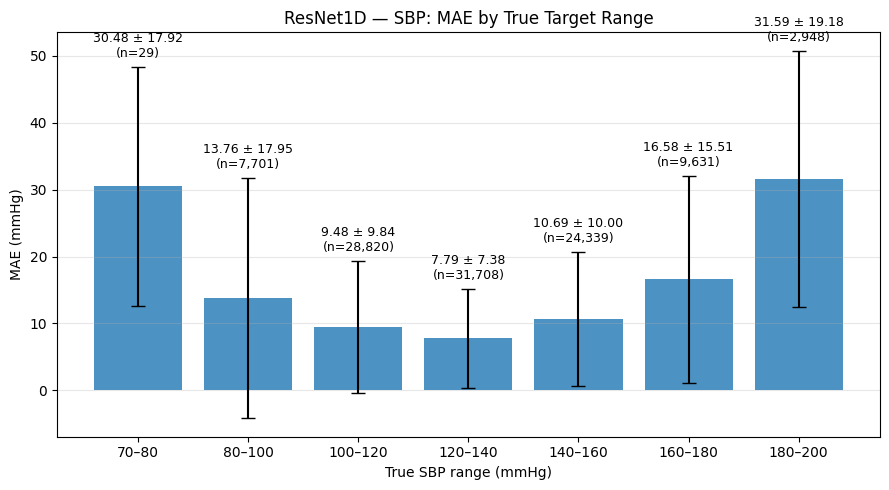

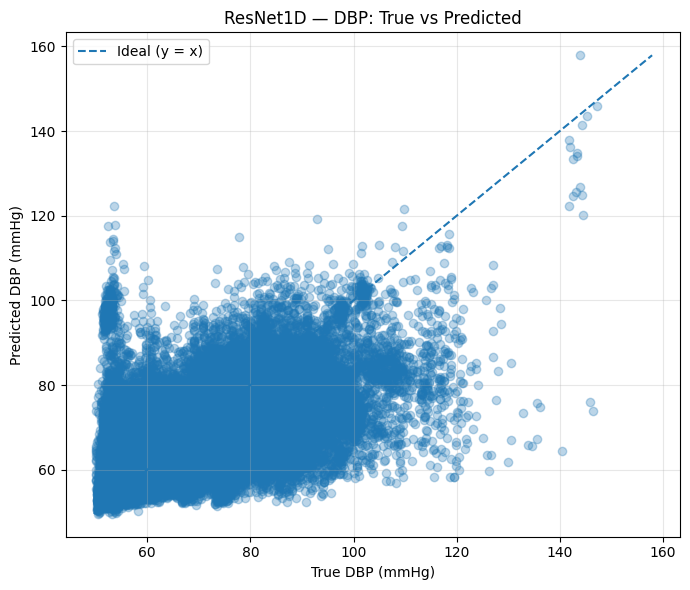

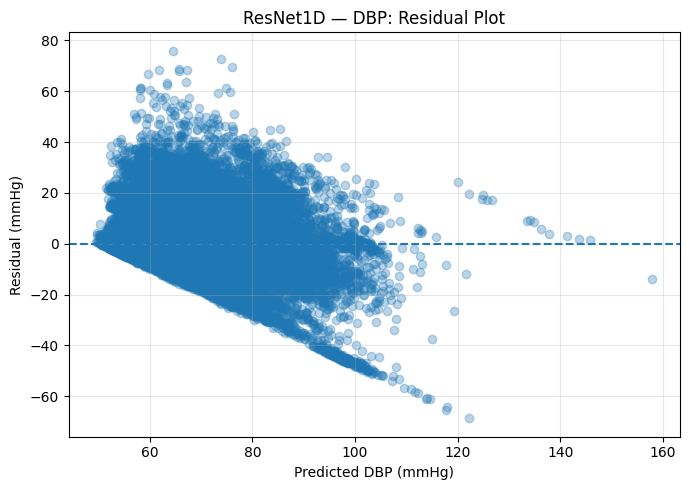

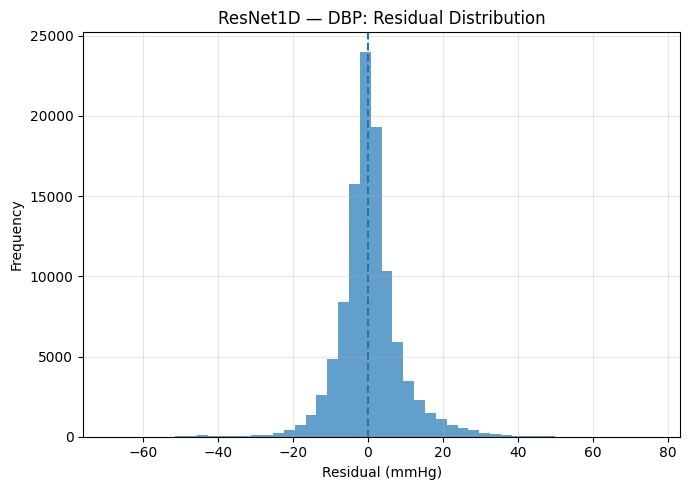

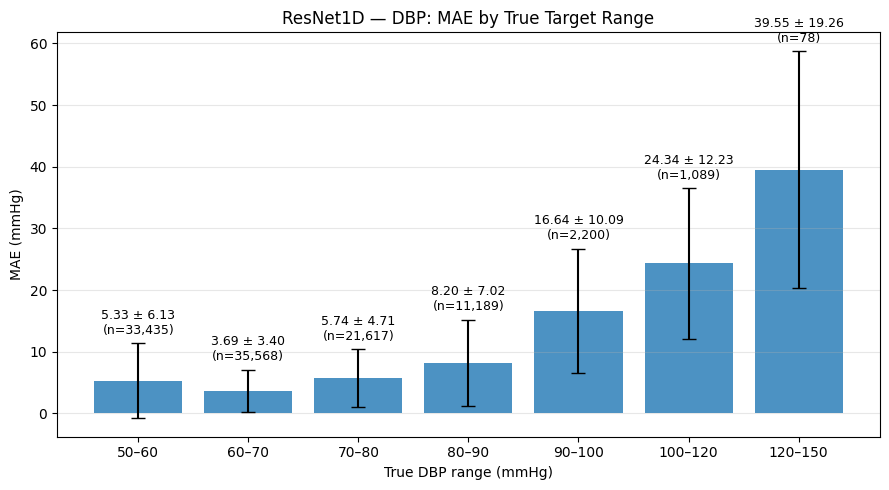

In [4]:
resnet_model, resnet_results = train_resnet1d(
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    batch_size=256,
    epochs=100,
    lr=1e-4,
    weight_decay=1e-3,
    patience=10
)

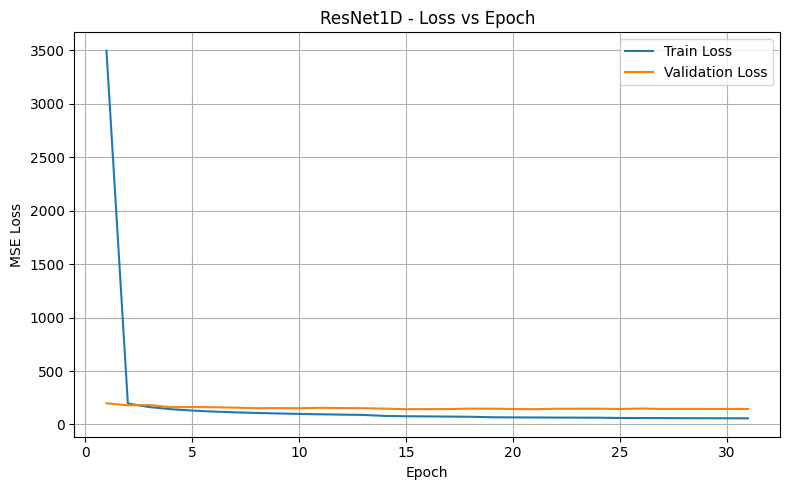

In [5]:
plot_loss_vs_epoch(
    resnet_results["history"],
    model_name="ResNet1D"
)

Number of VitalDB cases: 1963


ResNet1D VitalDB prediction: 100%|██████████| 1963/1963 [10:52<00:00,  3.01case/s]



RESNET1D
VITALDB ZERO-SHOT RESULTS
Total windows: 9271840

SBP
RMSE: 26.6395
MSE : 709.6635
R²  : -0.6604
MAE : 21.0393

DBP
RMSE: 14.7023
MSE : 216.1572
R²  : -0.3309
MAE : 11.5356

Plotting a random subsample of 50,000 of 9,271,840 windows (metrics above use all).


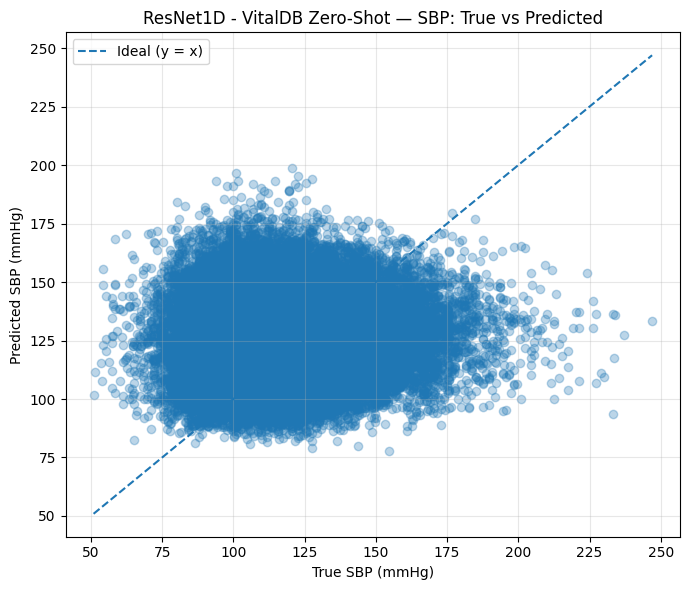

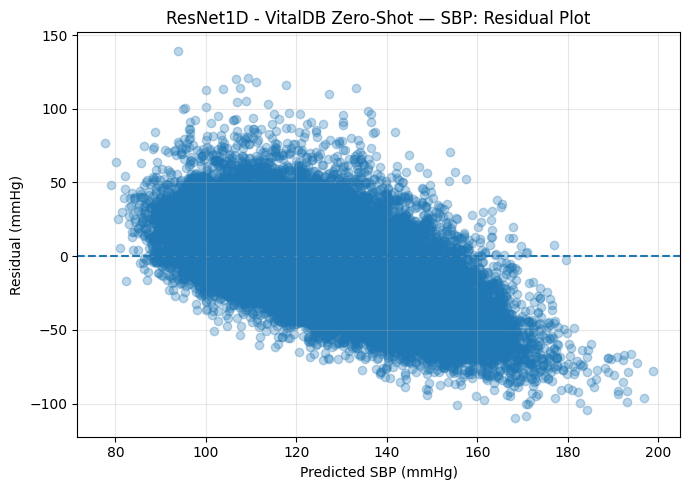

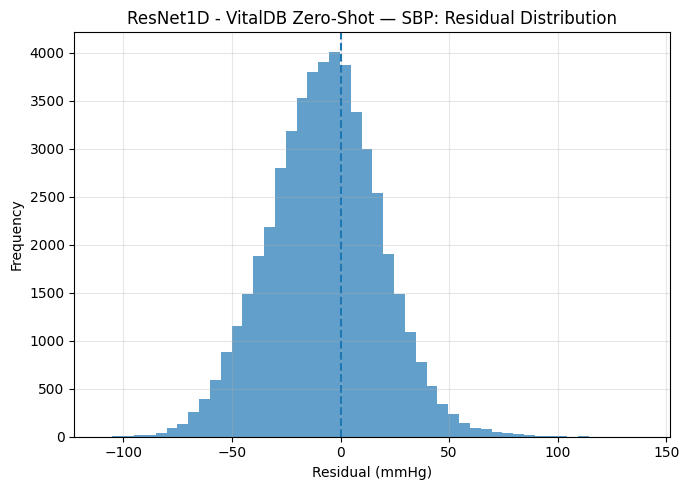

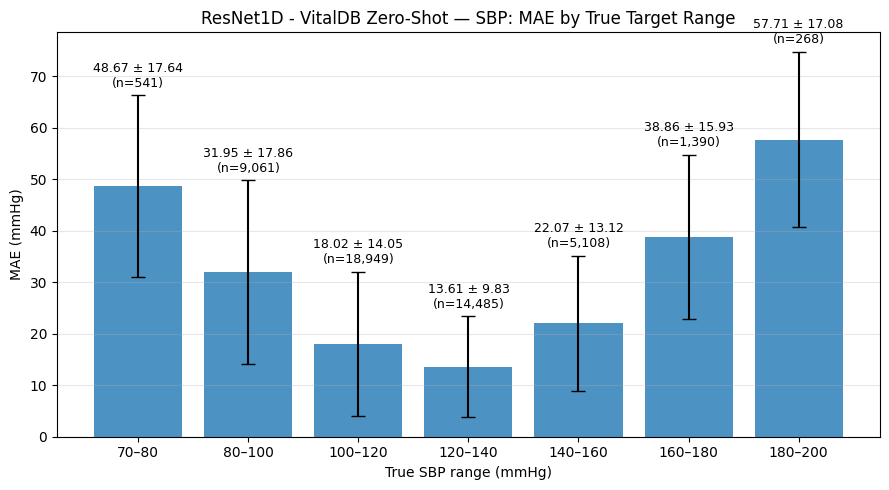

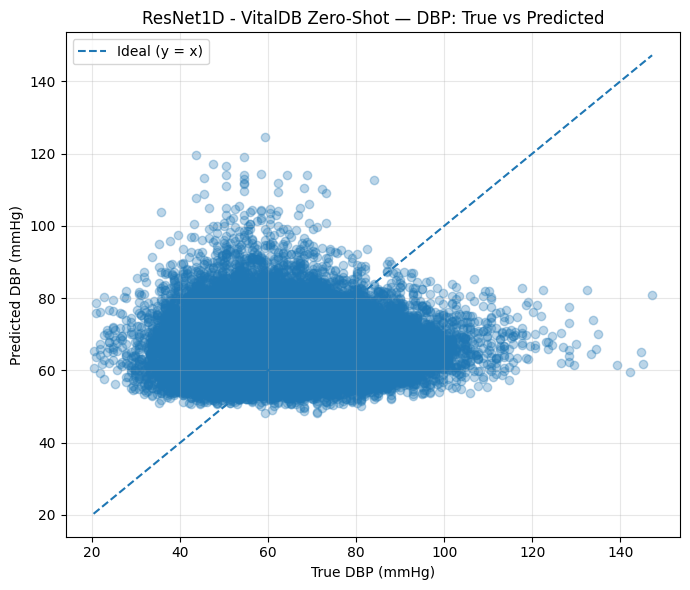

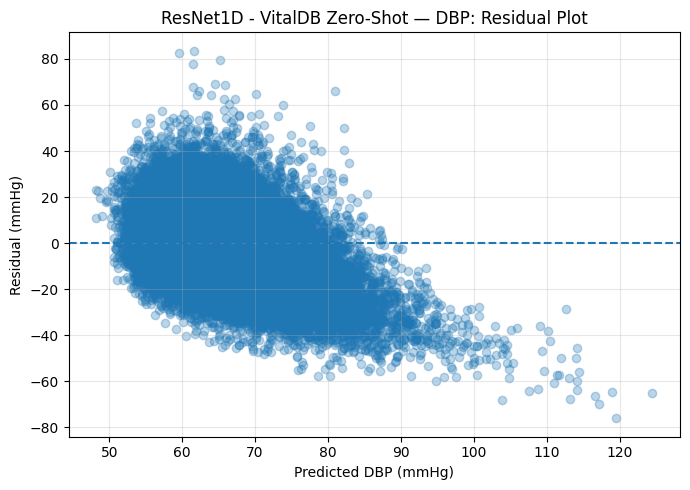

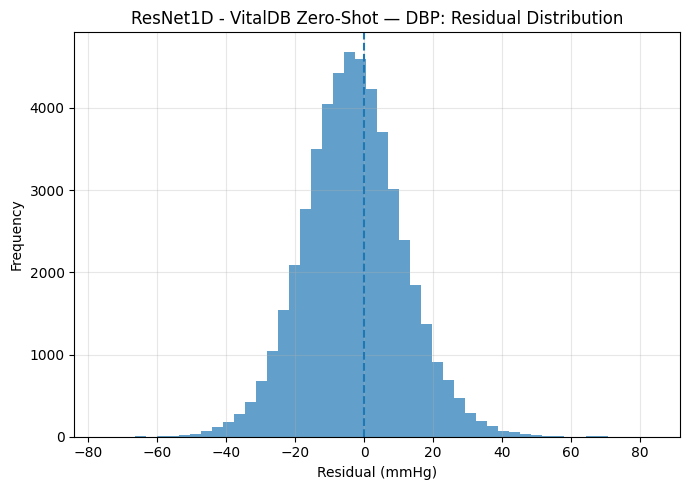

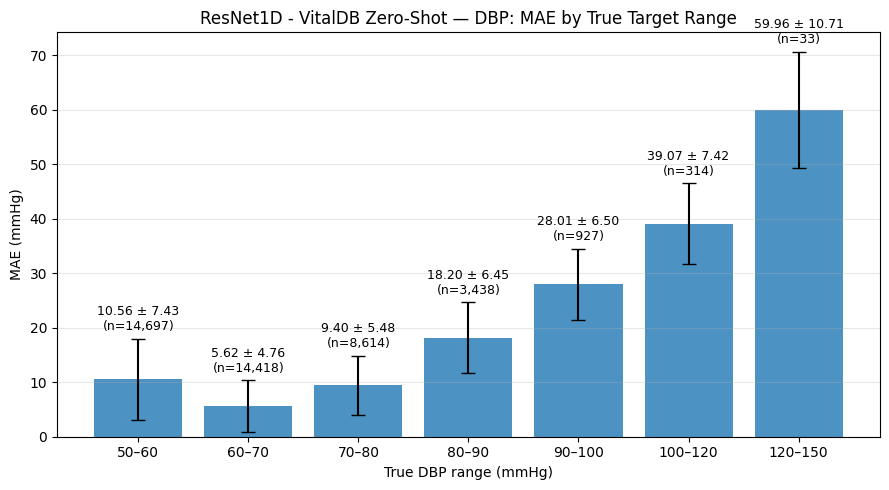

In [6]:
import os
import gc
import glob

import numpy as np
import torch
from tqdm import tqdm

import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from scipy.signal import find_peaks
from sklearn.model_selection import train_test_split


import warnings
warnings.filterwarnings("ignore")
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def print_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"RMSE: {rmse:.4f}")
    print(f"MSE : {mse:.4f}")
    print(f"R²  : {r2:.4f}")
    print(f"MAE : {mae:.4f}")
    

from matplotlib import pyplot as plt
import numpy as np

import numpy as np
import matplotlib.pyplot as plt


def plot_regression_results(
    y_true,
    y_pred,
    model_name,
    target_name
):

    # Convert to NumPy arrays
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    residuals = y_true - y_pred

    # ----------------------------------------
    # 1. TRUE VS PREDICTED
    # ----------------------------------------

    plt.figure(figsize=(7, 6))

    plt.scatter(
        y_true,
        y_pred,
        alpha=0.3
    )

    min_val = min(
        y_true.min(),
        y_pred.min()
    )

    max_val = max(
        y_true.max(),
        y_pred.max()
    )

    # Ideal y = x line
    plt.plot(
        [min_val, max_val],
        [min_val, max_val],
        linestyle="--",
        label="Ideal (y = x)"
    )

    plt.xlabel(
        f"True {target_name} (mmHg)"
    )

    plt.ylabel(
        f"Predicted {target_name} (mmHg)"
    )

    plt.title(
        f"{model_name} — {target_name}: "
        f"True vs Predicted"
    )

    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


    # ----------------------------------------
    # 2. RESIDUAL VS PREDICTED
    # ----------------------------------------

    plt.figure(figsize=(7, 5))

    plt.scatter(
        y_pred,
        residuals,
        alpha=0.3
    )

    # Zero-error line
    plt.axhline(
        0,
        linestyle="--"
    )

    plt.xlabel(
        f"Predicted {target_name} (mmHg)"
    )

    plt.ylabel(
        "Residual (mmHg)"
    )

    plt.title(
        f"{model_name} — {target_name}: "
        f"Residual Plot"
    )

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


    # ----------------------------------------
    # 3. RESIDUAL DISTRIBUTION
    # ----------------------------------------

    plt.figure(figsize=(7, 5))

    plt.hist(
        residuals,
        bins=50,
        alpha=0.7
    )

    # Zero-error line
    plt.axvline(
        0,
        linestyle="--"
    )

    plt.xlabel(
        "Residual (mmHg)"
    )

    plt.ylabel(
        "Frequency"
    )

    plt.title(
        f"{model_name} — {target_name}: "
        f"Residual Distribution"
    )

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


    # ----------------------------------------
    # 4. MAE VS TRUE TARGET RANGE
    #    WITH ERROR BARS
    # ----------------------------------------

    if target_name.upper() == "DBP":

        bins = [
            50,
            60,
            70,
            80,
            90,
            100,
            120,
            150
        ]

    else:

        # SBP
        bins = [
            70,
            80,
            100,
            120,
            140,
            160,
            180,
            200
        ]


    mae_values = []
    error_std = []
    sample_counts = []
    range_labels = []


    for i in range(len(bins) - 1):

        lower = bins[i]
        upper = bins[i + 1]

        mask = (
            (y_true >= lower) &
            (y_true < upper)
        )

        count = np.sum(mask)

        # Skip range if there are no samples
        if count == 0:
            continue


        # ----------------------------------------
        # Absolute errors for this BP range
        # ----------------------------------------

        absolute_errors = np.abs(
            y_true[mask] -
            y_pred[mask]
        )


        # Mean Absolute Error
        mae = np.mean(
            absolute_errors
        )


        # Standard deviation of absolute errors
        std = np.std(
            absolute_errors
        )


        mae_values.append(mae)
        error_std.append(std)
        sample_counts.append(count)

        range_labels.append(
            f"{lower}–{upper}"
        )


    # ----------------------------------------
    # Plot MAE + error bars
    # ----------------------------------------

    plt.figure(figsize=(9, 5))

    bars = plt.bar(
        range_labels,
        mae_values,
        yerr=error_std,
        capsize=5,
        alpha=0.8
    )


    plt.xlabel(
        f"True {target_name} range (mmHg)"
    )

    plt.ylabel(
        "MAE (mmHg)"
    )

    plt.title(
        f"{model_name} — {target_name}: "
        f"MAE by True Target Range"
    )


    # ----------------------------------------
    # Add MAE ± SD and sample count
    # ----------------------------------------

    for bar, mae, std, count in zip(
        bars,
        mae_values,
        error_std,
        sample_counts
    ):

        plt.text(
            bar.get_x() +
            bar.get_width() / 2,

            bar.get_height()+std+1,

            f"{mae:.2f} ± {std:.2f}\n"
            f"(n={count:,})",

            ha="center",
            va="bottom",
            fontsize=9
        )


    plt.grid(
        axis="y",
        alpha=0.3
    )

    plt.tight_layout()
    plt.show()


# Assumes print_metrics and plot_regression_results are already defined
# in your notebook, exactly as before.


def evaluate_resnet_vitaldb(
    model,
    base_dir,
    batch_size=256,
    device=None,
    max_plot_points=50_000,
    seed=0,
):
    """
    Memory-safe zero-shot evaluation on VitalDB case_*.npz files.

    Changes vs. the original:
      * np.load used as a context manager (file handle closed right away)
      * only one case in RAM at a time, explicitly freed after each case
      * no full-case float32 copy: each batch is cast on the fly
      * torch.from_numpy + inference_mode (no extra tensor copies / autograd)
      * predictions stored as float32
      * case_ids replaced by a compact int32 index + a list of case names
      * plots use a random subsample (metrics still use ALL windows)
    """

    # ============================================================
    # DEVICE
    # ============================================================

    if device is None:
        device = torch.device(
            "cuda" if torch.cuda.is_available() else "cpu"
        )

    model = model.to(device)
    model.eval()

    # ============================================================
    # FIND VITALDB FILES
    # ============================================================

    npz_files = sorted(
        glob.glob(os.path.join(base_dir, "case_*.npz"))
    )

    print("Number of VitalDB cases:", len(npz_files))

    if len(npz_files) == 0:
        raise ValueError(
            f"No case_*.npz files found in:\n{base_dir}"
        )

    # ============================================================
    # STORAGE (small: float32 predictions + labels only)
    # ============================================================

    sbp_true_all = []
    sbp_pred_all = []

    dbp_true_all = []
    dbp_pred_all = []

    case_names = []
    case_index_all = []   # int32 per window -> index into case_names

    # ============================================================
    # PREDICTION
    # ============================================================

    with torch.inference_mode():

        for case_idx, file in enumerate(
            tqdm(npz_files, desc="ResNet1D VitalDB prediction", unit="case")
        ):

            # ----------------------------------------------------
            # Load one case, close the file immediately
            # ----------------------------------------------------
            with np.load(file) as data:
                X = data["X"]
                y = data["y"]

            # (N, 1000) -> (N, 1, 1000)  (this is only a view)
            if X.ndim == 2:
                X = X[:, np.newaxis, :]

            sbp_true = y[:, 0].astype(np.float32)
            dbp_true = y[:, 1].astype(np.float32)

            n = len(X)

            case_names.append(
                os.path.basename(file).replace(".npz", "")
            )

            case_sbp_pred = np.empty(n, dtype=np.float32)
            case_dbp_pred = np.empty(n, dtype=np.float32)

            # ----------------------------------------------------
            # BATCHED PREDICTION
            # ----------------------------------------------------
            for start in range(0, n, batch_size):

                end = min(start + batch_size, n)

                # cast only this batch to float32 (no full-case copy)
                X_batch = np.ascontiguousarray(
                    X[start:end], dtype=np.float32
                )

                X_tensor = torch.from_numpy(X_batch).to(
                    device, non_blocking=True
                )

                predictions = model(X_tensor).float().cpu().numpy()

                case_sbp_pred[start:end] = predictions[:, 0]
                case_dbp_pred[start:end] = predictions[:, 1]

                del X_tensor, X_batch, predictions

            # ----------------------------------------------------
            # STORE
            # ----------------------------------------------------
            sbp_true_all.append(sbp_true)
            sbp_pred_all.append(case_sbp_pred)

            dbp_true_all.append(dbp_true)
            dbp_pred_all.append(case_dbp_pred)

            case_index_all.append(
                np.full(n, case_idx, dtype=np.int32)
            )

            # ----------------------------------------------------
            # FREE RAW SIGNAL BEFORE LOADING THE NEXT CASE
            # ----------------------------------------------------
            del X, y, sbp_true, dbp_true, case_sbp_pred, case_dbp_pred
            gc.collect()
            if device.type == "cuda":
                torch.cuda.empty_cache()

    # ============================================================
    # CONCATENATE ALL CASES
    # ============================================================

    sbp_true_all = np.concatenate(sbp_true_all)
    sbp_pred_all = np.concatenate(sbp_pred_all)

    dbp_true_all = np.concatenate(dbp_true_all)
    dbp_pred_all = np.concatenate(dbp_pred_all)

    case_index_all = np.concatenate(case_index_all)

    # ============================================================
    # RESULTS (computed on ALL windows)
    # ============================================================

    print("\n" + "=" * 60)
    print("RESNET1D")
    print("VITALDB ZERO-SHOT RESULTS")
    print("Total windows:", len(sbp_true_all))
    print("=" * 60)

    print("\nSBP")
    print_metrics(sbp_true_all, sbp_pred_all)

    print("\nDBP")
    print_metrics(dbp_true_all, dbp_pred_all)

    # ============================================================
    # PLOTS (subsampled so matplotlib doesn't blow up)
    # ============================================================

    total = len(sbp_true_all)

    if total > max_plot_points:
        rng = np.random.default_rng(seed)
        idx = np.sort(
            rng.choice(total, size=max_plot_points, replace=False)
        )
        print(
            f"\nPlotting a random subsample of {max_plot_points:,} "
            f"of {total:,} windows (metrics above use all)."
        )
    else:
        idx = np.arange(total)

    plot_regression_results(
        sbp_true_all[idx],
        sbp_pred_all[idx],
        model_name="ResNet1D - VitalDB Zero-Shot",
        target_name="SBP"
    )

    plot_regression_results(
        dbp_true_all[idx],
        dbp_pred_all[idx],
        model_name="ResNet1D - VitalDB Zero-Shot",
        target_name="DBP"
    )

    # ============================================================
    # RETURN
    # ============================================================

    results = {
        "sbp_true": sbp_true_all,
        "sbp_pred": sbp_pred_all,

        "dbp_true": dbp_true_all,
        "dbp_pred": dbp_pred_all,

        # compact replacement for the old per-window string list:
        #   case_names[case_index[i]] -> case id of window i
        "case_index": case_index_all,
        "case_names": case_names,
    }

    return results

resnet_vitaldb_results = evaluate_resnet_vitaldb(
    model=resnet_model,
    base_dir=BASE_DIR,
    batch_size=256
)

## SE Activation ##

Device: cuda
X_train: torch.Size([829483, 1, 625])
y_train: torch.Size([829483, 2])
X_val: torch.Size([104736, 1, 625])
y_val: torch.Size([104736, 2])
X_test: torch.Size([105176, 1, 625])
y_test: torch.Size([105176, 2])
Epoch 01/100 | Train Loss: 3621.8450 | Val Loss: 280.7373 | Train SBP RMSE: 78.701 | Train DBP RMSE: 32.401 | Val SBP RMSE: 21.424 | Val DBP RMSE: 10.124 | LR: 1.00e-04
Epoch 02/100 | Train Loss: 233.9734 | Val Loss: 198.8644 | Train SBP RMSE: 19.023 | Train DBP RMSE: 10.298 | Val SBP RMSE: 17.569 | Val DBP RMSE: 9.437 | LR: 1.00e-04
Epoch 03/100 | Train Loss: 191.7485 | Val Loss: 178.8717 | Train SBP RMSE: 17.165 | Train DBP RMSE: 9.427 | Val SBP RMSE: 16.618 | Val DBP RMSE: 9.033 | LR: 1.00e-04
Epoch 04/100 | Train Loss: 164.4295 | Val Loss: 172.7256 | Train SBP RMSE: 15.837 | Train DBP RMSE: 8.834 | Val SBP RMSE: 16.406 | Val DBP RMSE: 8.734 | LR: 1.00e-04
Epoch 05/100 | Train Loss: 145.2161 | Val Loss: 172.2578 | Train SBP RMSE: 14.821 | Train DBP RMSE: 8.413 | Val 

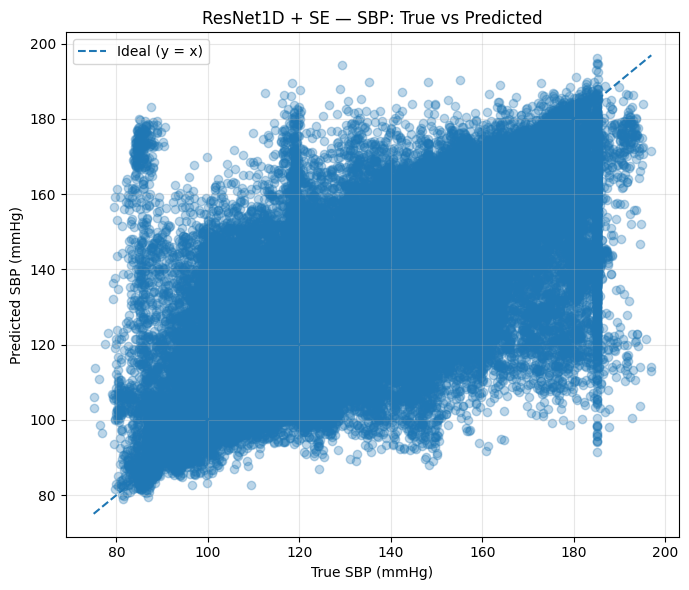

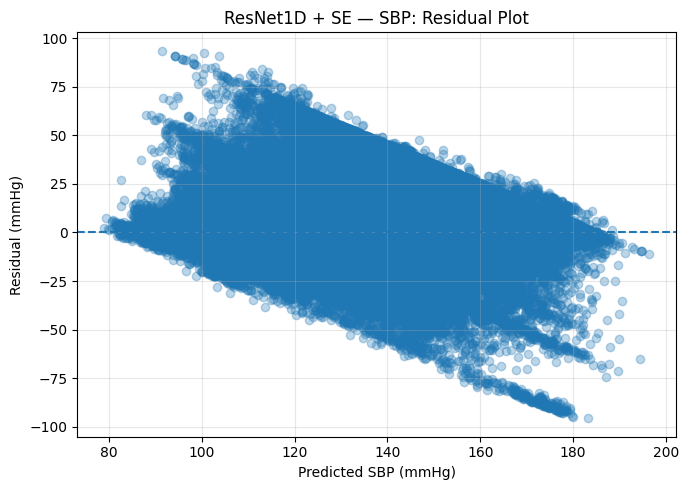

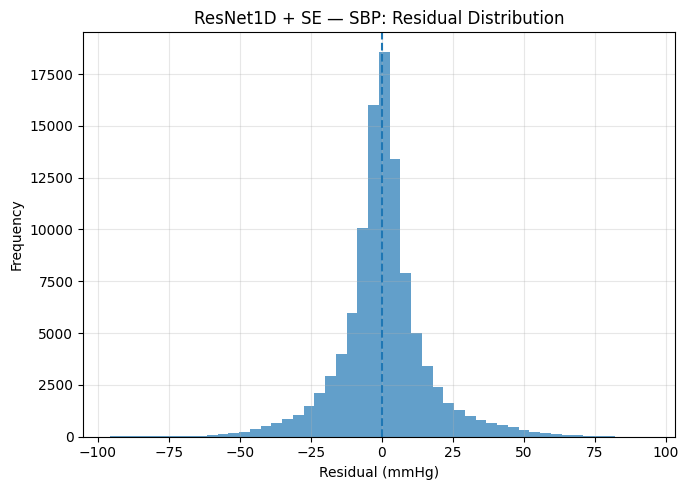

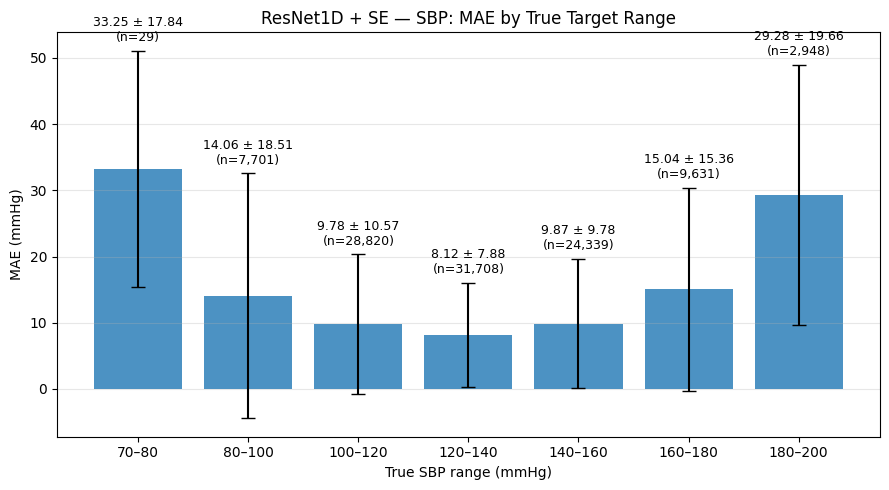

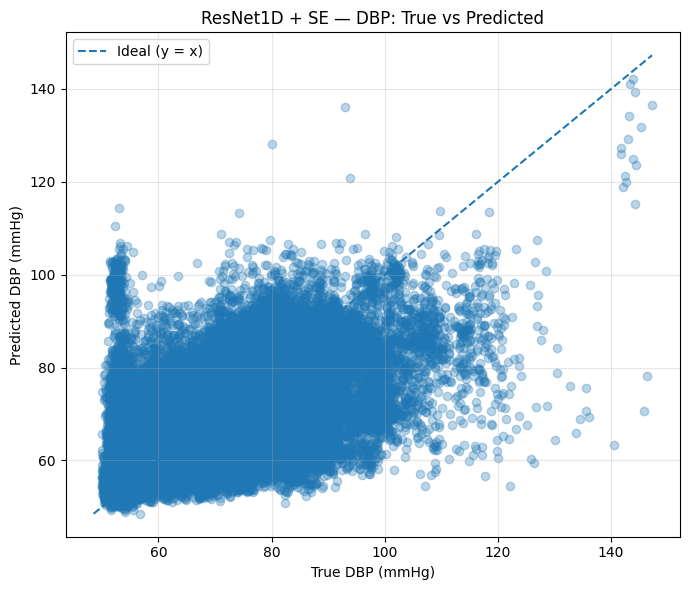

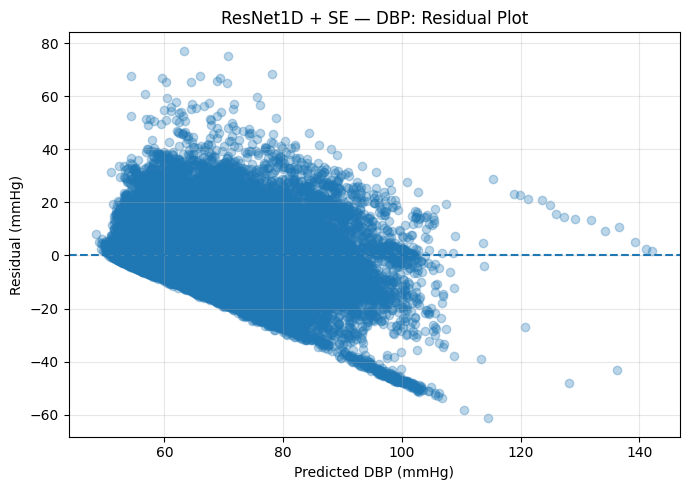

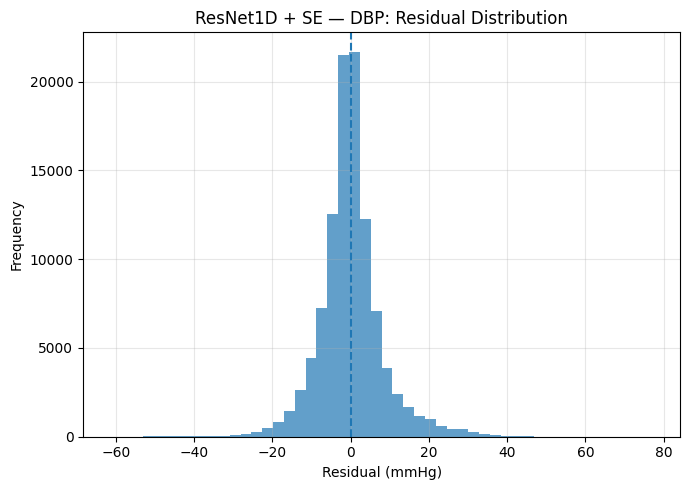

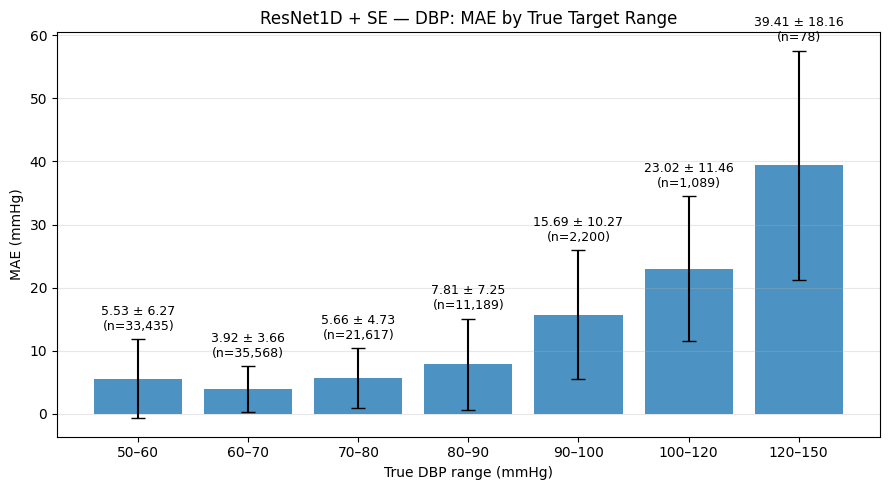

In [7]:
resnet_se_model, resnet_se_results = train_resnet1d_se(
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    batch_size=256,
    epochs=100,
    lr=1e-4,
    weight_decay=1e-3,
    patience=10,
    reduction=16
)

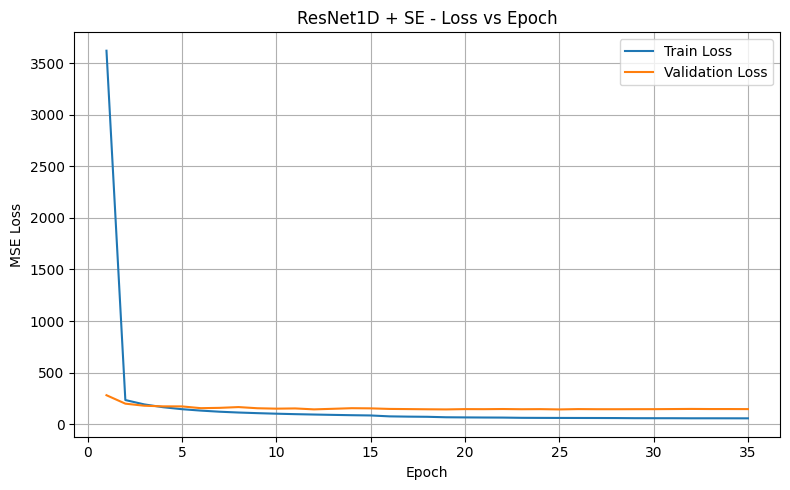

In [8]:
plot_loss_vs_epoch(
    resnet_se_results["history"],
    model_name="ResNet1D + SE"
)

Number of VitalDB cases: 1963


ResNet1D VitalDB prediction: 100%|██████████| 1963/1963 [11:55<00:00,  2.74case/s]



RESNET1D
VITALDB ZERO-SHOT RESULTS
Total windows: 9271840

SBP
RMSE: 28.4570
MSE : 809.8021
R²  : -0.8947
MAE : 22.7236

DBP
RMSE: 14.9559
MSE : 223.6799
R²  : -0.3772
MAE : 11.8848

Plotting a random subsample of 50,000 of 9,271,840 windows (metrics above use all).


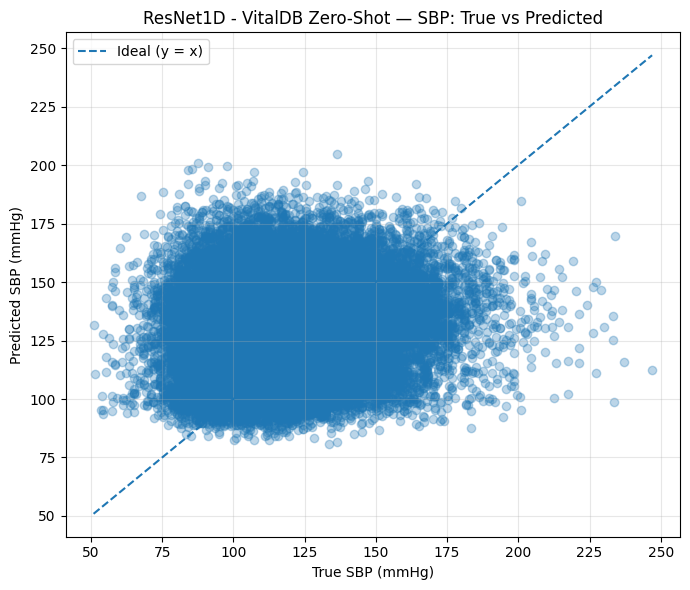

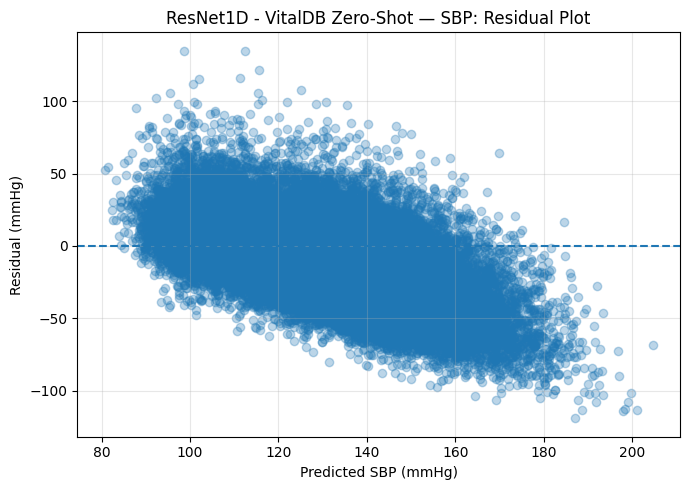

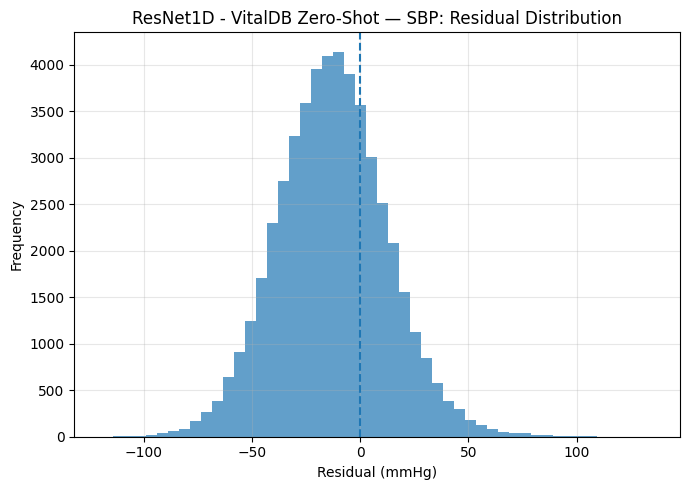

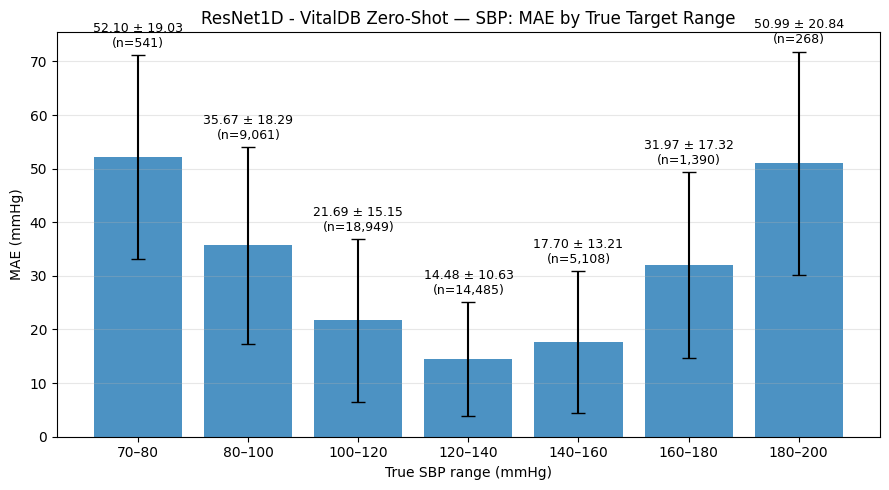

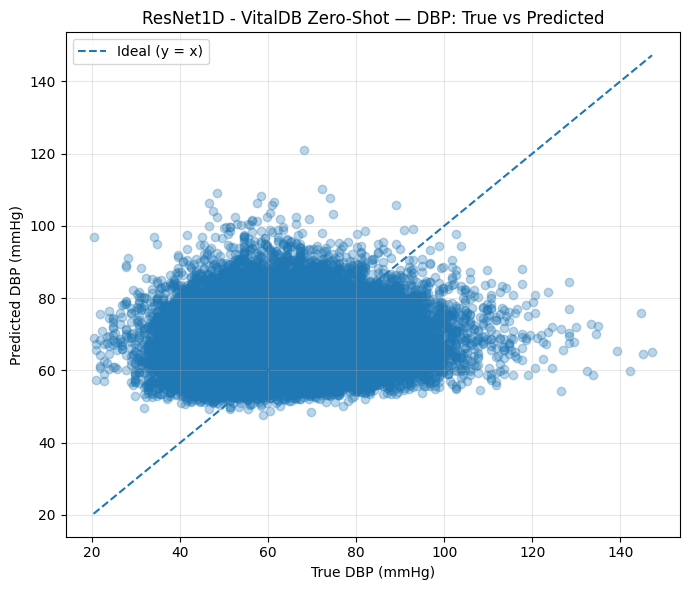

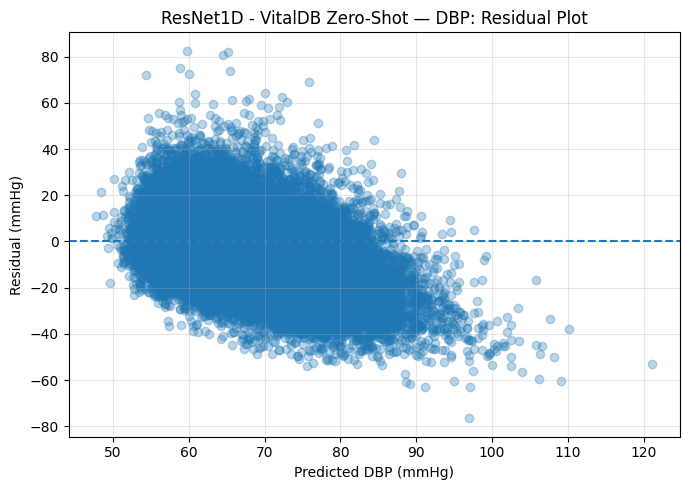

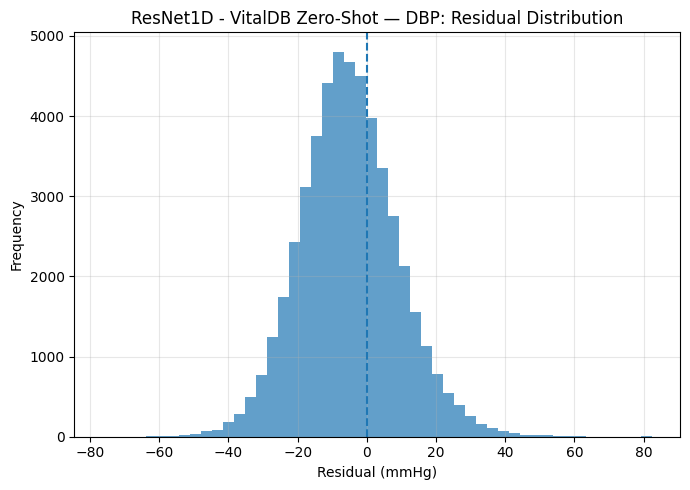

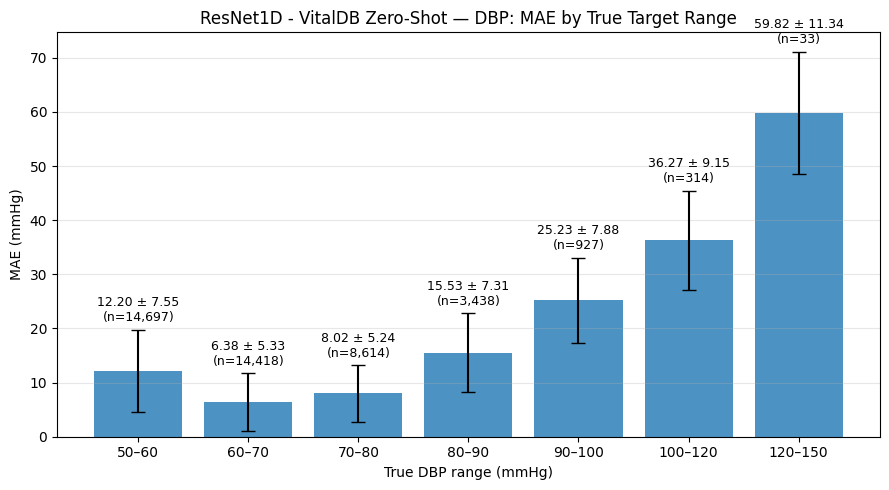

In [9]:
resnet_se_vitaldb_results = evaluate_resnet_vitaldb(
    model=resnet_se_model,
    base_dir=BASE_DIR,
    batch_size=256
)

## CBAM ##

Device: cuda
X_train: torch.Size([829483, 1, 625])
X_val: torch.Size([104736, 1, 625])
X_test: torch.Size([105176, 1, 625])
Epoch 01/100 | Train Loss: 3485.2433 | Val Loss: 245.6426 | Train SBP RMSE: 76.967 | Train DBP RMSE: 32.352 | Val SBP RMSE: 19.385 | Val DBP RMSE: 10.747 | LR: 1.00e-04
Epoch 02/100 | Train Loss: 211.4621 | Val Loss: 184.2233 | Train SBP RMSE: 17.995 | Train DBP RMSE: 9.955 | Val SBP RMSE: 16.882 | Val DBP RMSE: 9.136 | LR: 1.00e-04
Epoch 03/100 | Train Loss: 176.3124 | Val Loss: 171.4038 | Train SBP RMSE: 16.388 | Train DBP RMSE: 9.168 | Val SBP RMSE: 16.202 | Val DBP RMSE: 8.962 | LR: 1.00e-04
Epoch 04/100 | Train Loss: 153.4269 | Val Loss: 179.3030 | Train SBP RMSE: 15.226 | Train DBP RMSE: 8.662 | Val SBP RMSE: 16.645 | Val DBP RMSE: 9.031 | LR: 1.00e-04
Epoch 05/100 | Train Loss: 137.1240 | Val Loss: 157.7734 | Train SBP RMSE: 14.356 | Train DBP RMSE: 8.255 | Val SBP RMSE: 15.580 | Val DBP RMSE: 8.534 | LR: 1.00e-04
Epoch 06/100 | Train Loss: 125.3211 | Val L

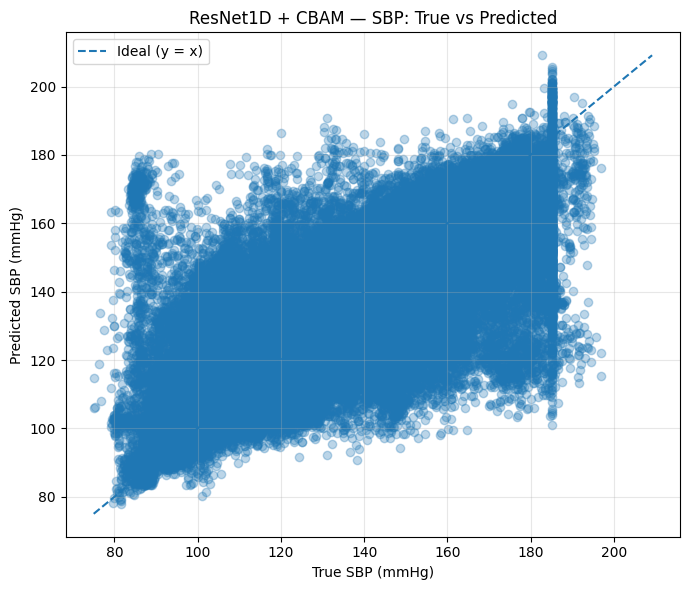

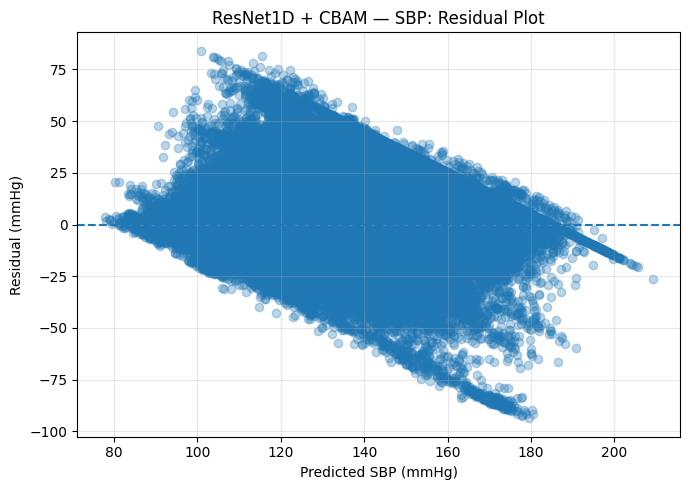

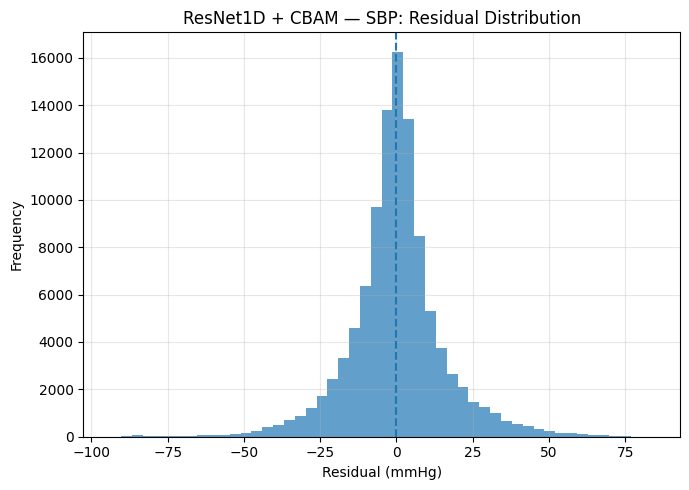

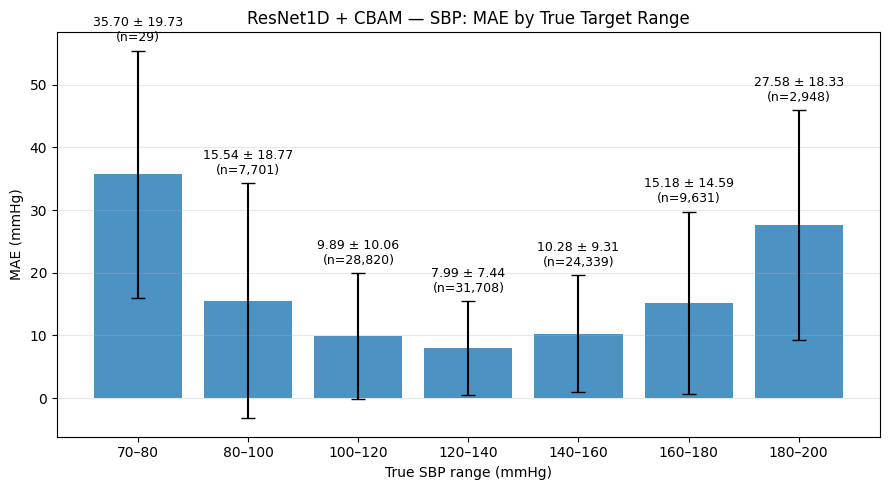

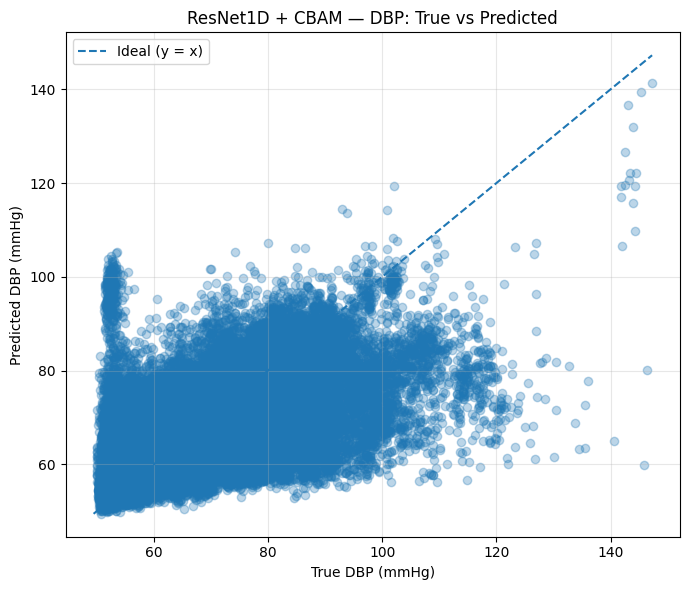

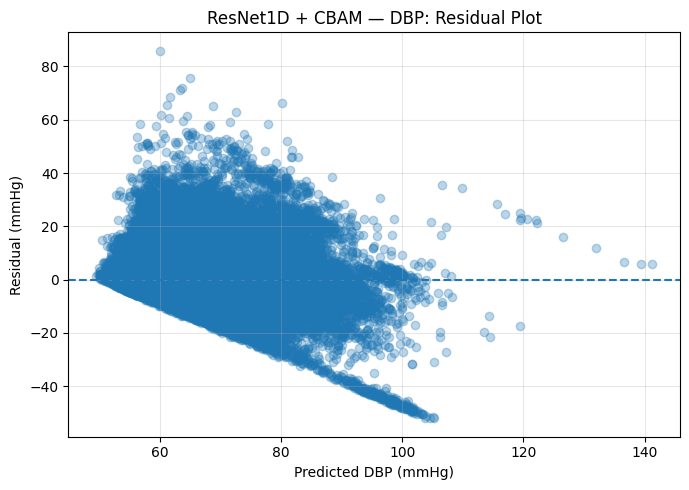

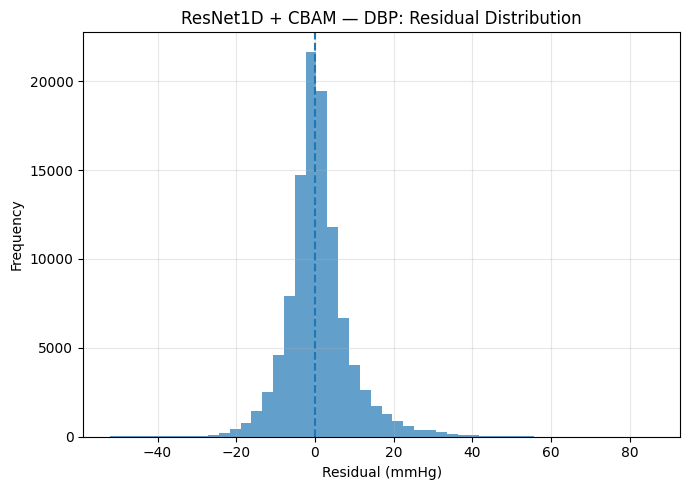

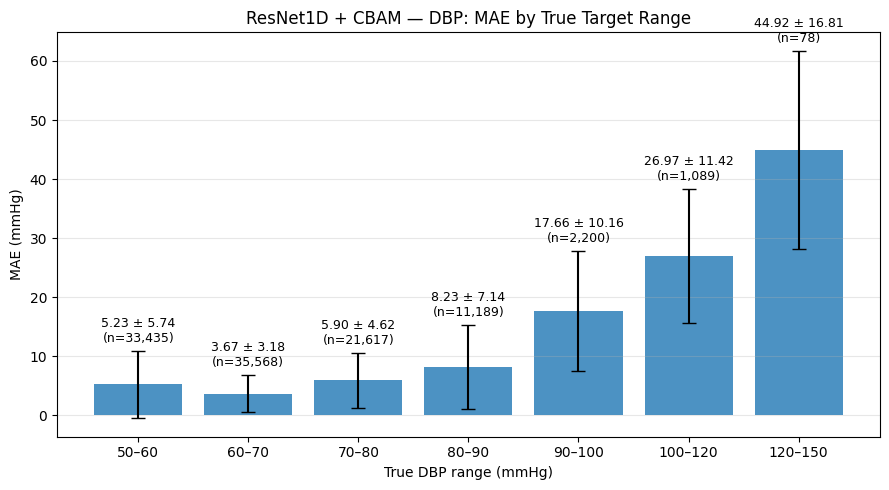

In [10]:
cbam_model, cbam_results = train_resnet1d_cbam(
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    batch_size=256,
    epochs=100,
    lr=1e-4,
    weight_decay=1e-3,
    patience=10
)

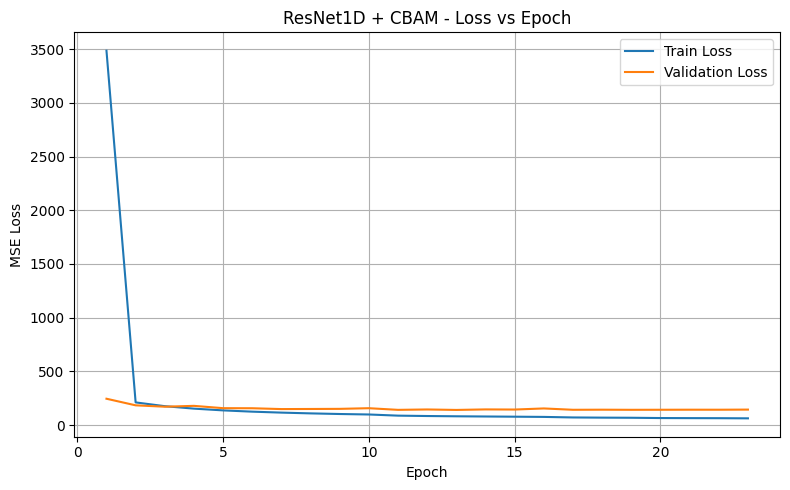

In [11]:
plot_loss_vs_epoch(
    cbam_results["history"],
    model_name="ResNet1D + CBAM"
)

Number of VitalDB cases: 1963


ResNet1D VitalDB prediction: 100%|██████████| 1963/1963 [13:45<00:00,  2.38case/s]



RESNET1D
VITALDB ZERO-SHOT RESULTS
Total windows: 9271840

SBP
RMSE: 26.7161
MSE : 713.7495
R²  : -0.6700
MAE : 21.1431

DBP
RMSE: 13.9673
MSE : 195.0854
R²  : -0.2012
MAE : 11.0237

Plotting a random subsample of 50,000 of 9,271,840 windows (metrics above use all).


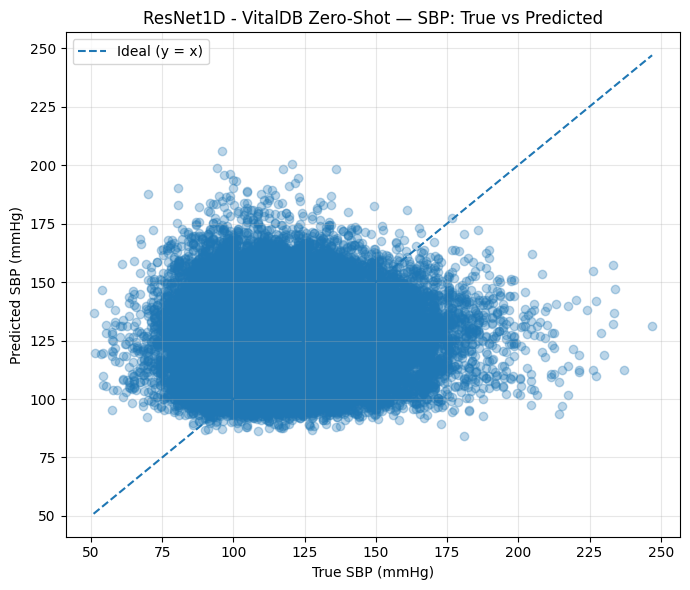

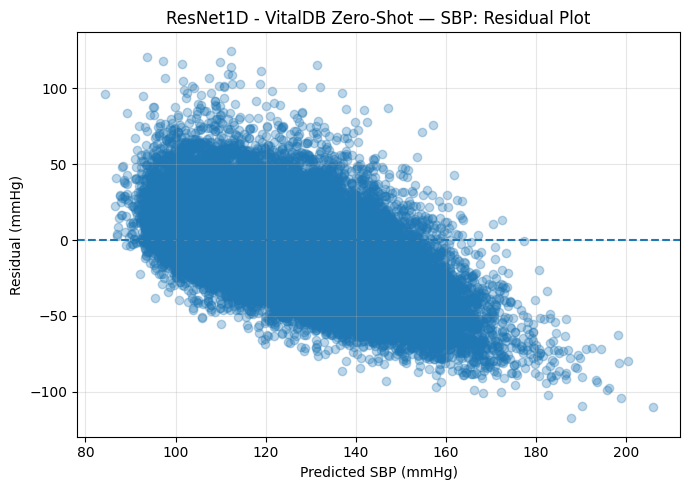

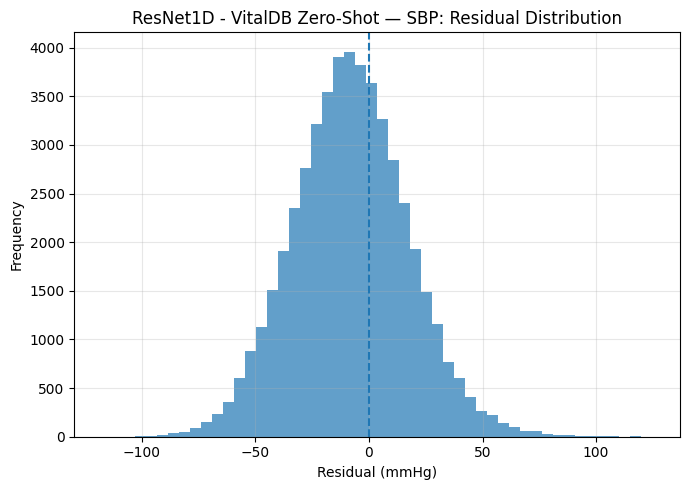

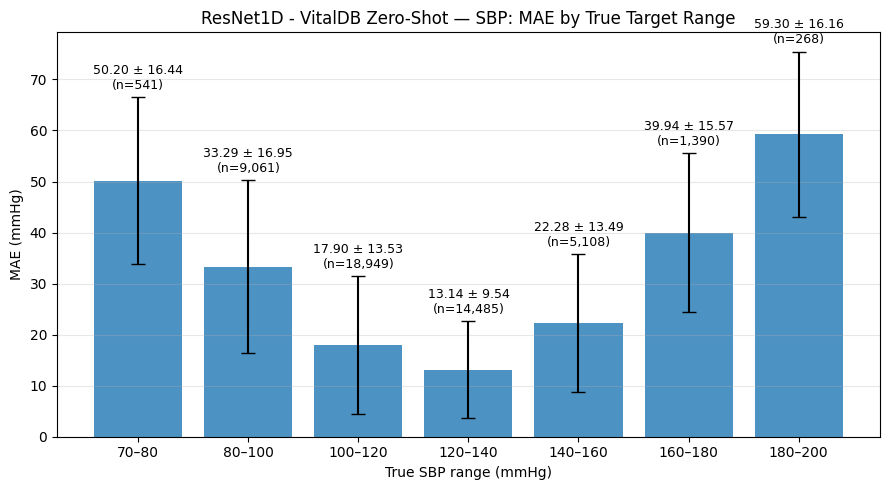

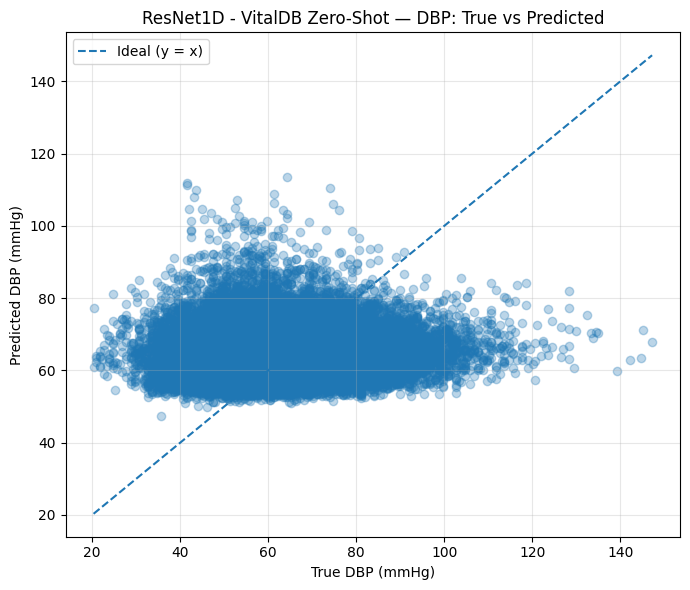

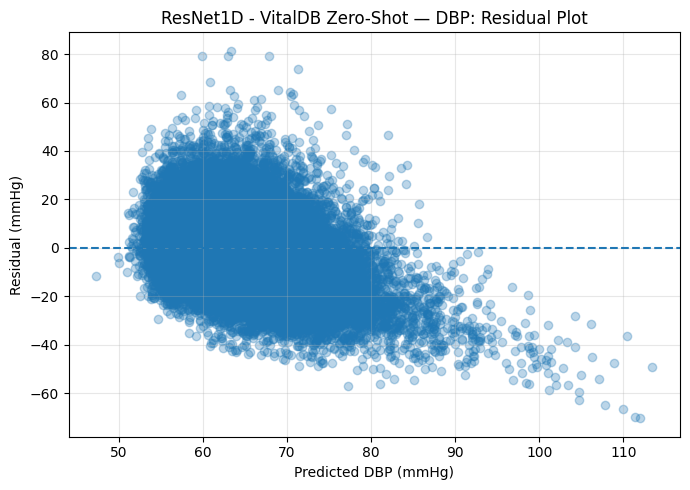

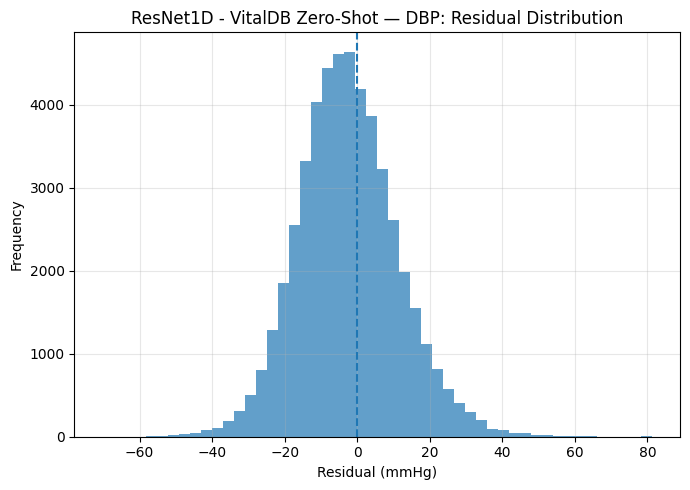

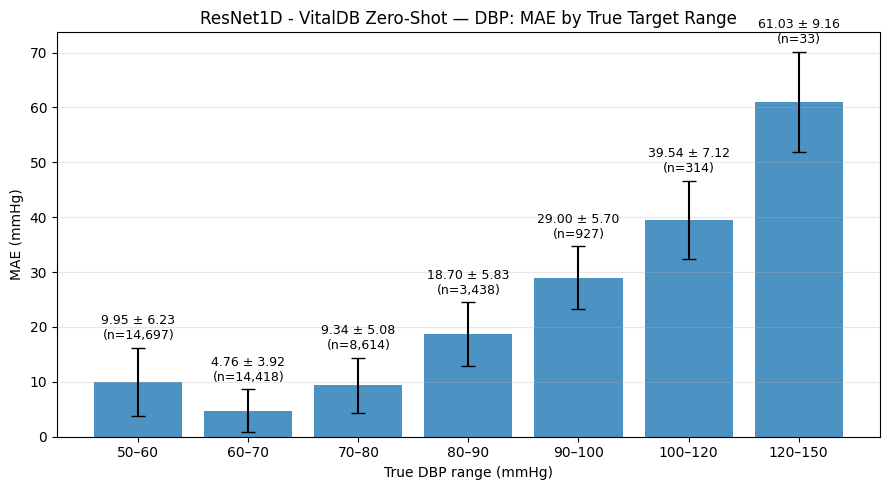

In [12]:
cbam_vitaldb_results = evaluate_resnet_vitaldb(
    model=cbam_model,
    base_dir=BASE_DIR,
    batch_size=256
)

## DILATED ## 

Device: cuda
X_train: torch.Size([829483, 1, 625])
X_val: torch.Size([104736, 1, 625])
X_test: torch.Size([105176, 1, 625])
Epoch 01/100 | Train Loss: 3373.4104 | Val Loss: 218.3535 | Train SBP RMSE: 75.615 | Train DBP RMSE: 32.081 | Val SBP RMSE: 18.383 | Val DBP RMSE: 9.939 | LR: 1.00e-04
Epoch 02/100 | Train Loss: 195.5068 | Val Loss: 186.7518 | Train SBP RMSE: 17.239 | Train DBP RMSE: 9.687 | Val SBP RMSE: 17.094 | Val DBP RMSE: 9.016 | LR: 1.00e-04
Epoch 03/100 | Train Loss: 168.1230 | Val Loss: 175.6374 | Train SBP RMSE: 15.952 | Train DBP RMSE: 9.043 | Val SBP RMSE: 16.544 | Val DBP RMSE: 8.807 | LR: 1.00e-04
Epoch 04/100 | Train Loss: 152.7262 | Val Loss: 166.8830 | Train SBP RMSE: 15.165 | Train DBP RMSE: 8.687 | Val SBP RMSE: 16.111 | Val DBP RMSE: 8.613 | LR: 1.00e-04
Epoch 05/100 | Train Loss: 142.1047 | Val Loss: 162.7769 | Train SBP RMSE: 14.593 | Train DBP RMSE: 8.440 | Val SBP RMSE: 15.891 | Val DBP RMSE: 8.546 | LR: 1.00e-04
Epoch 06/100 | Train Loss: 133.4383 | Val Lo

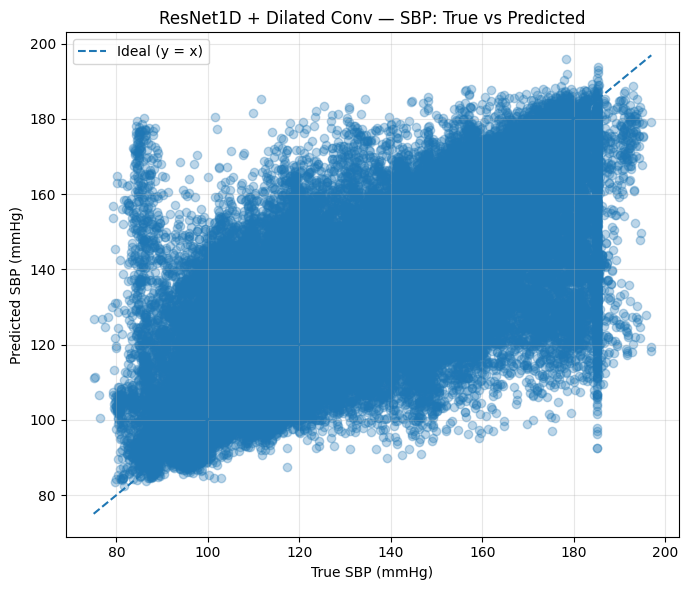

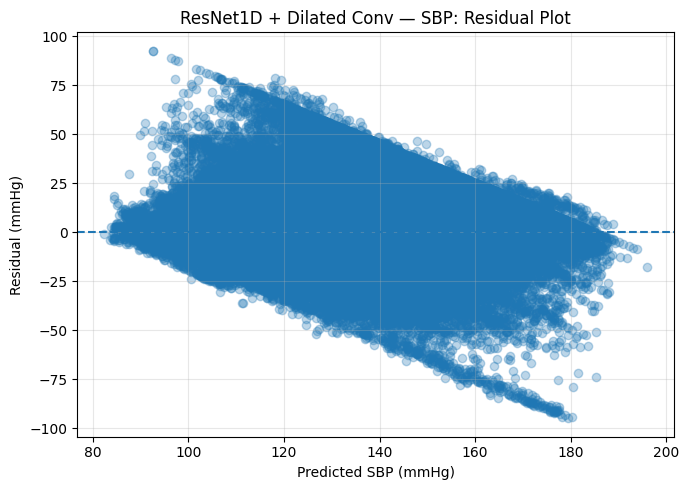

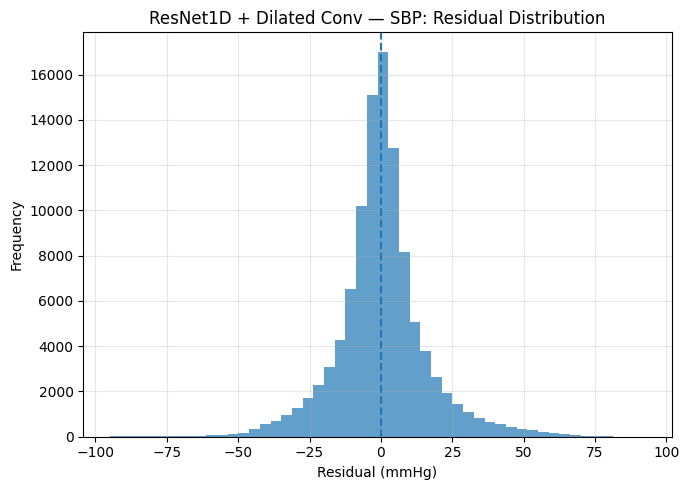

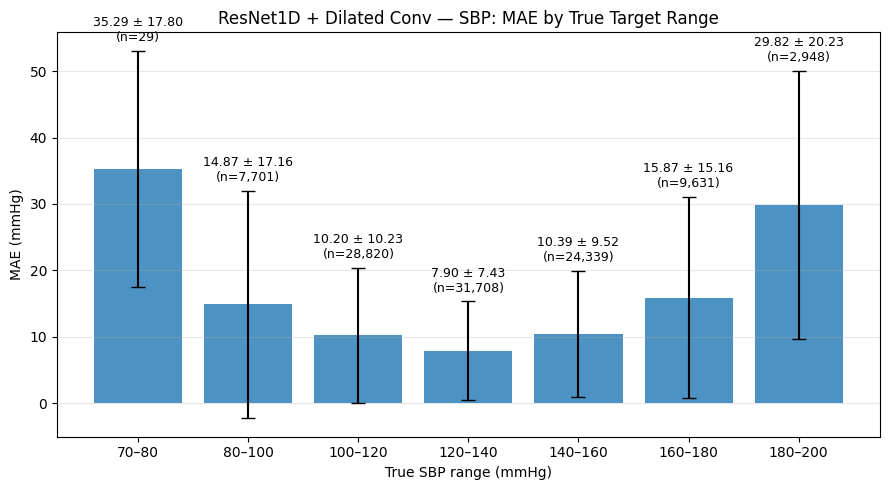

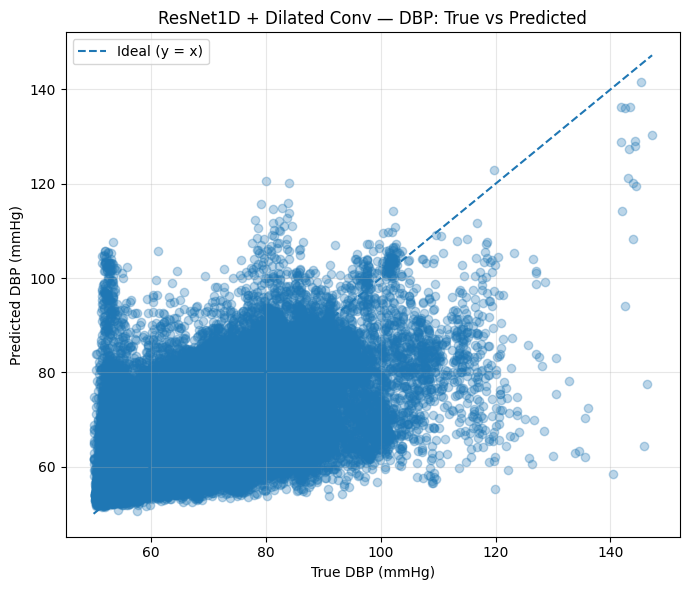

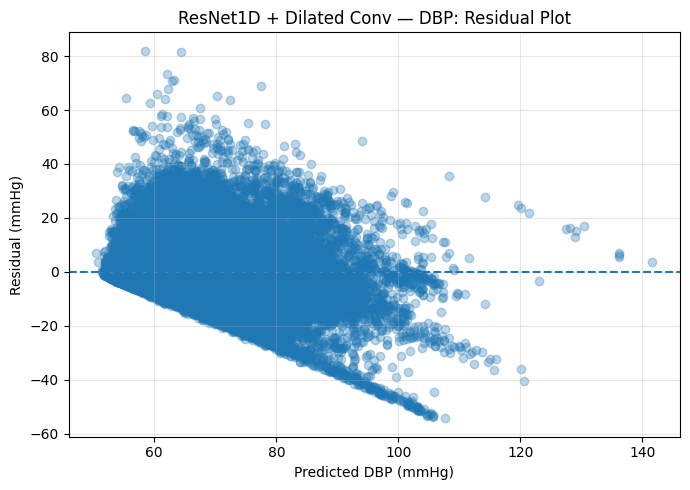

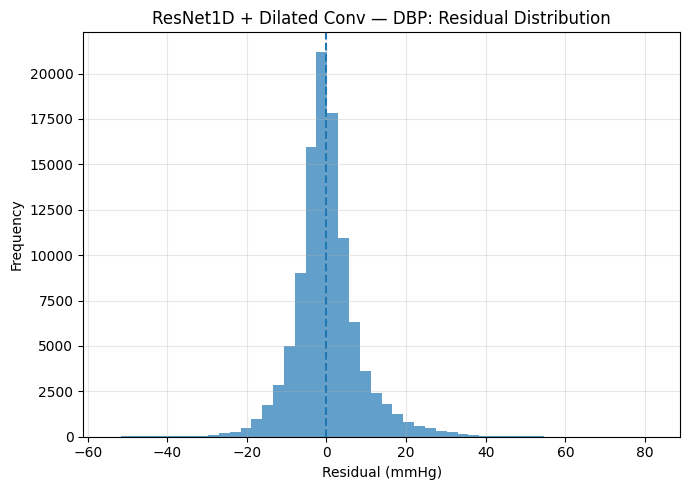

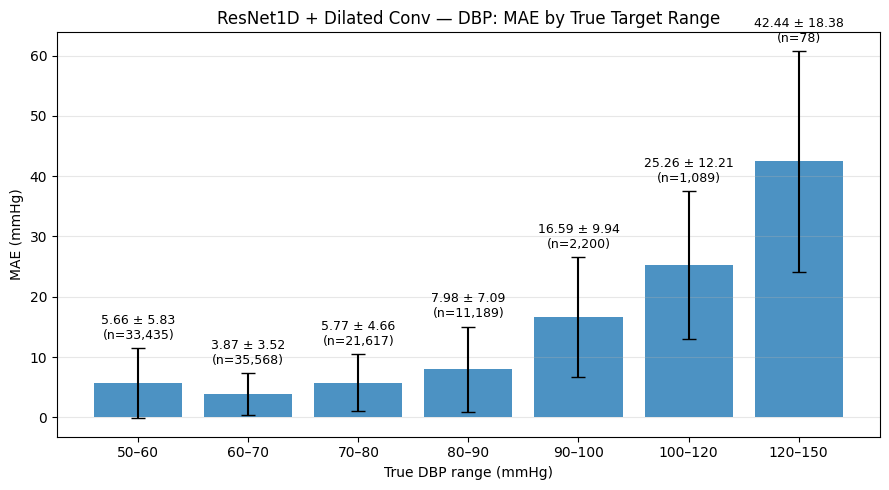

In [13]:
dilated_model, dilated_results = train_resnet1d_dilated(
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    batch_size=256,
    epochs=100,
    lr=1e-4,
    weight_decay=1e-3,
    patience=10
)

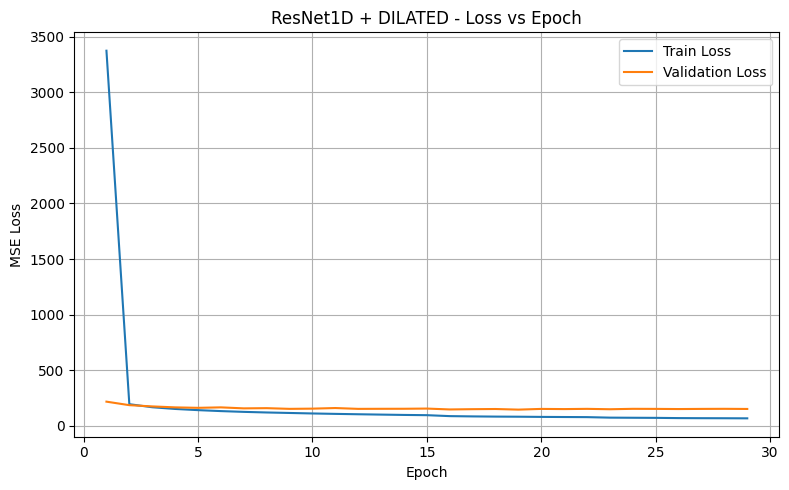

In [14]:
plot_loss_vs_epoch(
    dilated_results["history"],
    model_name="ResNet1D + DILATED"
)

Number of VitalDB cases: 1963


ResNet1D VitalDB prediction: 100%|██████████| 1963/1963 [11:13<00:00,  2.91case/s]



RESNET1D
VITALDB ZERO-SHOT RESULTS
Total windows: 9271840

SBP
RMSE: 25.8560
MSE : 668.5302
R²  : -0.5642
MAE : 20.5550

DBP
RMSE: 14.3556
MSE : 206.0832
R²  : -0.2689
MAE : 11.3872

Plotting a random subsample of 50,000 of 9,271,840 windows (metrics above use all).


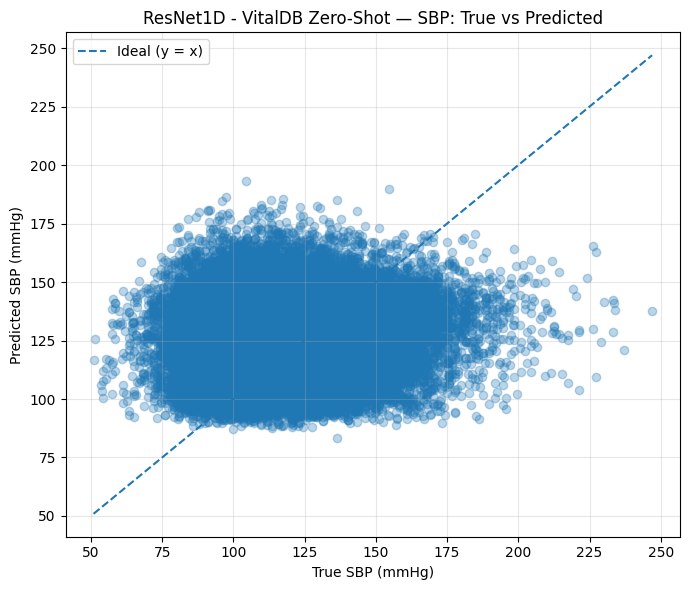

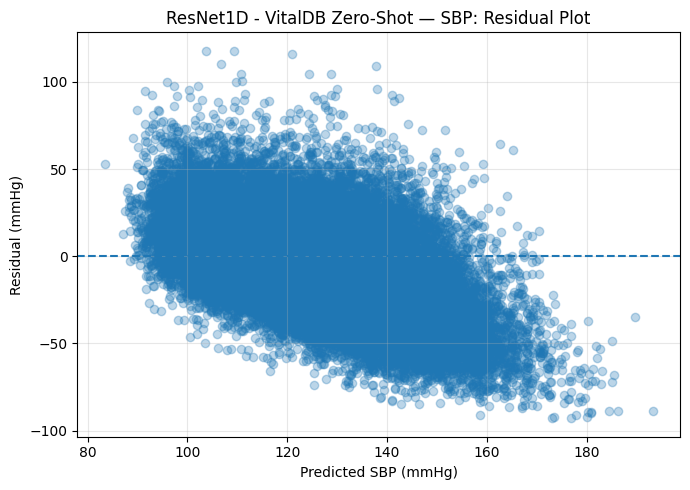

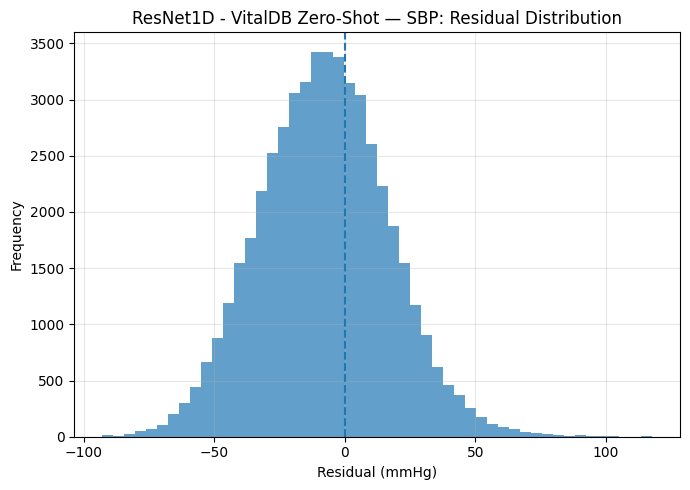

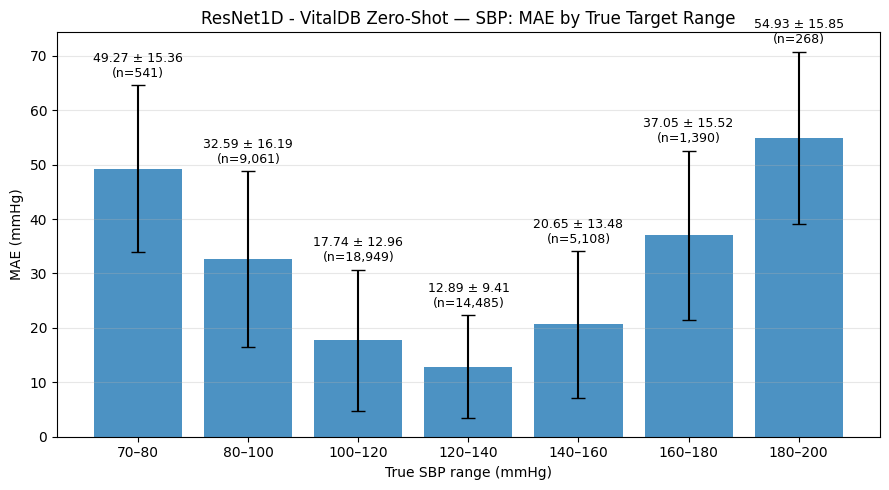

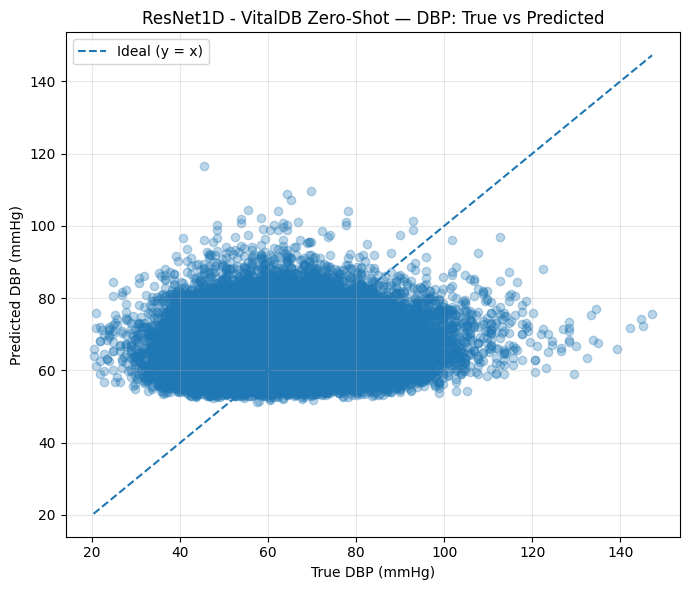

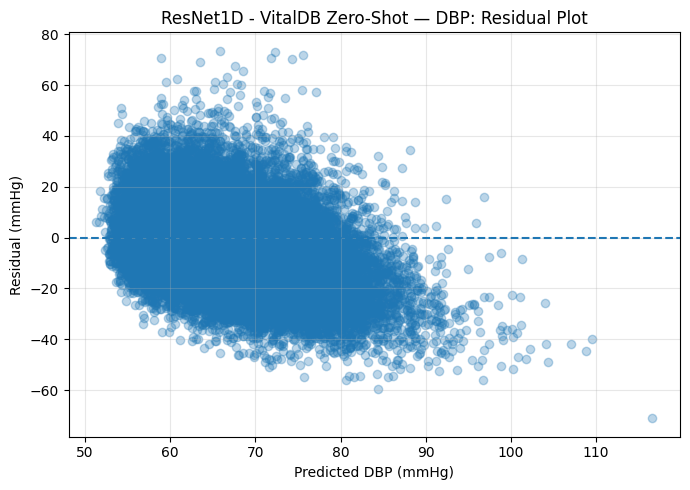

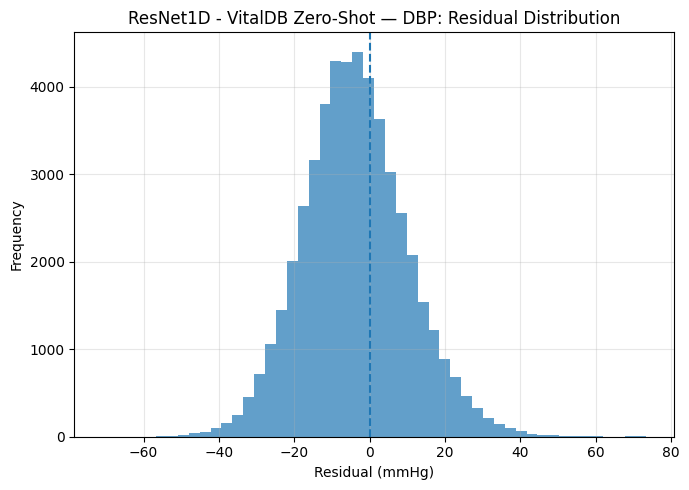

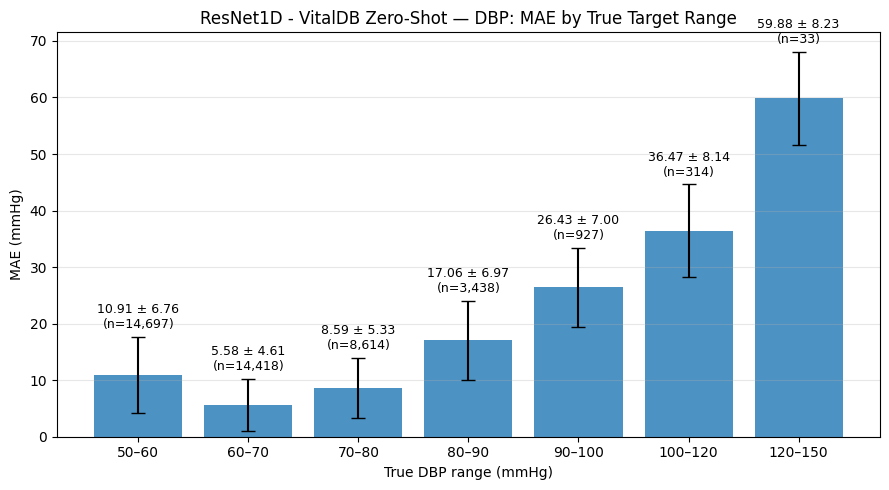

In [15]:
dilated_results = evaluate_resnet_vitaldb(
    model=dilated_model,
    base_dir=BASE_DIR,
    batch_size=256
)